In [1]:
%pip install torch


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install sentence-transformers transformers


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import torch
from sentence_transformers import SentenceTransformer
import transformers
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import os
import json

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 1000)

print("Libraries imported successfully! Environment is ready.")

/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully! Environment is ready.


In [4]:
file_path = "../data/processed/preprocessed_employee_task_data.csv"
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

print("--- Column Names & Data Types ---")
print(df.dtypes.to_string())
print("\n")

print("--- Missing-Value Summary ---")
missing_values = df.isnull().sum()
missing_filtered = missing_values[missing_values > 0]
if missing_filtered.empty:
    print("No missing values found (excluding deadlines).")
else:
    print(missing_filtered.to_string())
print("\n")

print("--- Unique Values for Key Columns ---")
key_columns = [
    "Employee_ID",
    "Task_ID",
    "Project_Name",
    "Employee_Department",
    "Employee_Job_Position",
    "Task_Priority"
]
for col in key_columns:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
print("\n")

print("--- First 5 Rows ---")
display(df.head())

Dataset Shape: 11,630 rows x 19 columns

--- Column Names & Data Types ---
Date                                            str
Task_ID                                         str
Task_Name                                       str
FLAG_LEAKAGE_Work_Description                   str
FLAG_LEAKAGE_Hours_Spent                    float64
Project_Name                                    str
Employee_ID                                     str
Employee_Department                             str
Employee_Job_Position                           str
Task_Description                                str
FLAG_LEAKAGE_Timesheet_Work_Logs                str
Task_Priority                                   str
Estimated_Planned_Hours                     float64
FLAG_LEAKAGE_Actual_Hours_Spent             float64
FLAG_LEAKAGE_Timesheet_Logs_Count             int64
FLAG_LEAKAGE_Task_Stage                         str
Created_Date                                    str
Deadline_Date                            

,Date,Task_ID,Task_Name,FLAG_LEAKAGE_Work_Description,FLAG_LEAKAGE_Hours_Spent,Project_Name,Employee_ID,Employee_Department,Employee_Job_Position,Task_Description,FLAG_LEAKAGE_Timesheet_Work_Logs,Task_Priority,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,FLAG_LEAKAGE_Task_Stage,Created_Date,Deadline_Date,FLAG_LEAKAGE_All_Collaborating_Employees
0,2026-09-14,TSK-1640,odoo sh maintain,db backup and restore in test,0.25,Hovael Project,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installin...,add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installing and install the basereport xls...,Low,0.0,14.25,27,Project Preparation,2026-02-05,NaN,W M I L Wijesinghe
1,2026-09-14,TSK-1881,odoo sh maintain,db backup and restore in test,0.25,Ceylon Eco Spices,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup ...,add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup adn restore in live | add invent...,Low,0.0,6.50,13,Developments,2026-03-19,NaN,W M I L Wijesinghe
2,2026-09-14,TSK-182,odoo.sh maintaing,add addons,0.25,Mihiri Bakemart (Pvt)Ltd - Development,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo.sh maintaing. work details: add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add add...,add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add addon and test addon witchanuka and ...,Low,0.0,40.75,29,Ongoing,2025-06-09,NaN,W M I L Wijesinghe
3,2026-09-14,TSK-2884,development meeting,/,0.00,Cygnus One,EMP-55,Colombo Branch,Project Manager,development meeting. work details: intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael...,"intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael,mihiri and steel mart | rfq app ch...",Low,0.0,9.42,13,Miscellaneous,2026-07-06,NaN,"W M I L Wijesinghe, K R V Dias, A R M S Madusanka, Malshi Jayanthi"
4,2026-09-14,TSK-405,other tasks (mention on description),get privillages to charith's new github account on odoo sh projects and the all repositories,0.50,Cygnus One,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),other tasks (mention on description). work details: self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create g...,self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create grn import template | landed cost | create demo datab...,Low,0.0,162.18,69,Miscellaneous,2025-07-14,NaN,"H.M.C.S Thilakarathna, Sadaruwan Bandara, L H P S S Pathirana, I G C Bandara, W M I L Wijesinghe, G L Sachini"


In [5]:
TARGET = "Employee_ID"

print(
    f"Model Objective: Rank suitable employees "\
    f"for newly created tasks.\n"
)

FLAGGED_LEAKAGE_COLS = [
    c for c in df.columns
    if c.startswith("FLAG_LEAKAGE_")
]

POST_ASSIGNMENT_COLS = list(
    dict.fromkeys(
        FLAGGED_LEAKAGE_COLS
        + [
            "Hours_Spent",
            "Work_Description",
            "Actual_Hours_Spent",
            "Timesheet_Work_Logs",
            "Timesheet_Logs_Count",
            "Task_Stage",
            "All_Collaborating_Employees",
        ]
    )
)

POST_ASSIGNMENT_COLS = [
    c for c in POST_ASSIGNMENT_COLS
    if c in df.columns
]

print("Post-assignment columns that will NEVER become model features:")
for c in POST_ASSIGNMENT_COLS:
    print(" -", c)


Model Objective: Rank suitable employees for newly created tasks.

Post-assignment columns that will NEVER become model features:
 - FLAG_LEAKAGE_Work_Description
 - FLAG_LEAKAGE_Hours_Spent
 - FLAG_LEAKAGE_Timesheet_Work_Logs
 - FLAG_LEAKAGE_Actual_Hours_Spent
 - FLAG_LEAKAGE_Timesheet_Logs_Count
 - FLAG_LEAKAGE_Task_Stage
 - FLAG_LEAKAGE_All_Collaborating_Employees


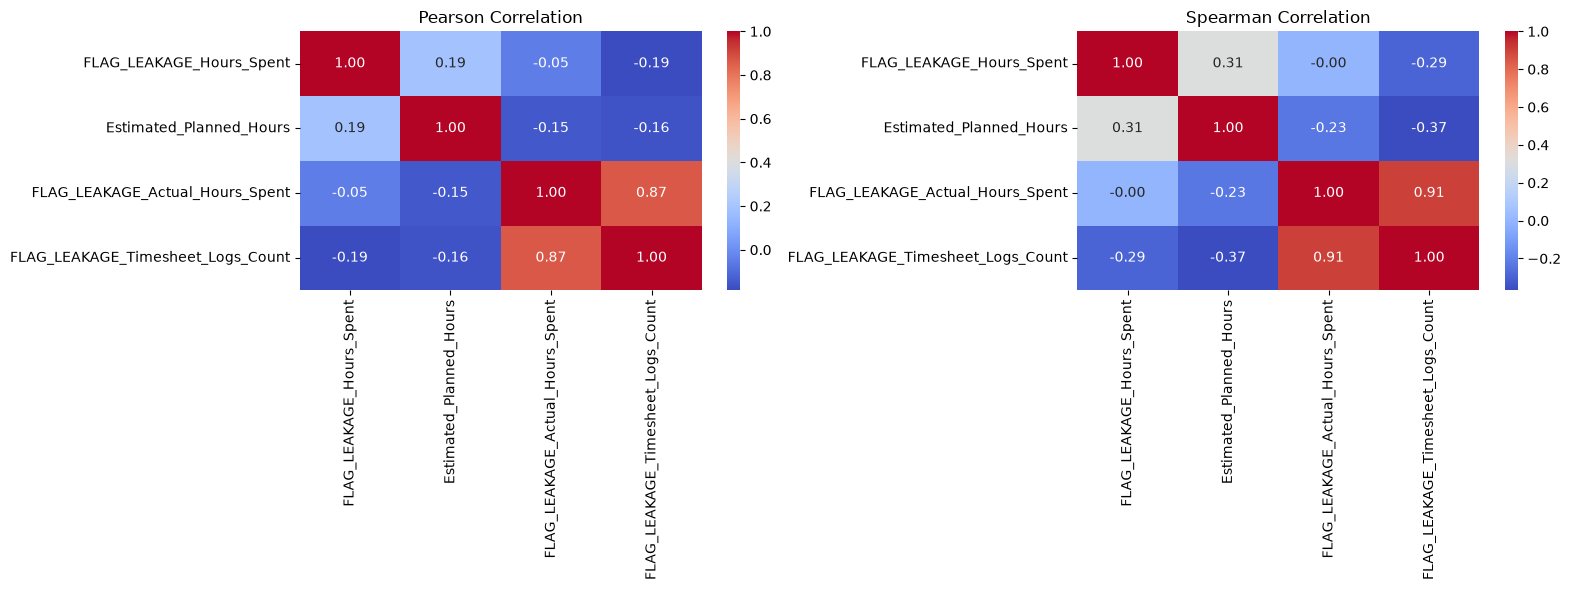

Highly Correlated Numerical Pairs (Pearson | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.869

Highly Correlated Numerical Pairs (Spearman | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.905

--- Mutual Information Scores (Target: Employee_ID) ---


,Feature,Mutual_Information
4,Employee_Job_Position,2.519176
1,Task_Name,2.264791
3,Employee_Department,1.309500
0,Project_Name,1.226753
2,Task_Priority,0.032660



--- Target Distribution (Employee_ID) ---
Total Unique Employees: 46
Average Tasks per Employee: 237.35
Median Tasks per Employee: 119.00
Most Frequently Assigned: EMP-5 (1010 tasks)
Least Frequently Assigned: EMP-1 (2 tasks)

Top 10 Employees by Assignment Count:


,Task_Count,count
0,EMP-5,1010
1,EMP-10,959
2,EMP-11,946
3,EMP-17,604
4,EMP-4,547
5,EMP-16,528
6,EMP-12,516
7,EMP-27,508
8,EMP-7,498
9,EMP-21,456



Bottom 5 Employees by Assignment Count:


,Task_Count,count
0,EMP-59,12
1,EMP-24,9
2,EMP-25,6
3,EMP-67,2
4,EMP-1,2


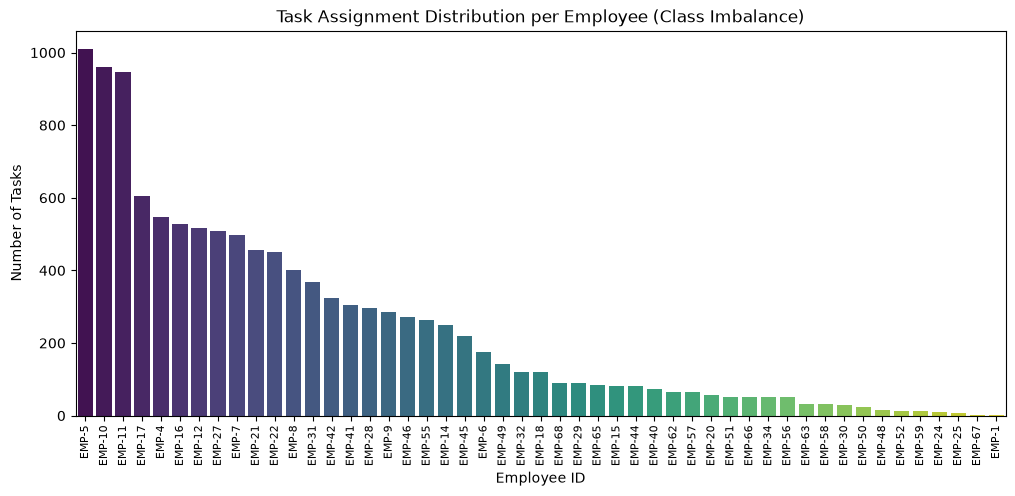

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Employee_ID" in numerical_cols: numerical_cols.remove("Employee_ID")
if "Task_ID" in numerical_cols: numerical_cols.remove("Task_ID")

pearson_corr = df[numerical_cols].corr(method="pearson")
spearman_corr = df[numerical_cols].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()

def get_highly_correlated_pairs(corr_matrix, threshold=0.70):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    return pairs

print("Highly Correlated Numerical Pairs (Pearson | >= 0.70):")
pearson_pairs = get_highly_correlated_pairs(pearson_corr)
for p in pearson_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")

print("\nHighly Correlated Numerical Pairs (Spearman | >= 0.70):")
spearman_pairs = get_highly_correlated_pairs(spearman_corr)
for p in spearman_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")

from sklearn.metrics import mutual_info_score
print("\n--- Mutual Information Scores (Target: Employee_ID) ---")
cat_features = [
    "Project_Name",
    "Task_Name",
    "Task_Priority",
    "Employee_Department",
    "Employee_Job_Position"
]
mi_scores = []
for col in cat_features:
    if col in df.columns:
        col_data = df[col].fillna("Unknown").astype(str)
        target_data = df["Employee_ID"].astype(str)
        mi = mutual_info_score(col_data, target_data)
        mi_scores.append({"Feature": col, "Mutual_Information": mi})
mi_df = pd.DataFrame(mi_scores).sort_values(by="Mutual_Information", ascending=False)
display(mi_df)

print("\n--- Target Distribution (Employee_ID) ---")
employee_counts = df["Employee_ID"].value_counts()
print(f"Total Unique Employees: {employee_counts.nunique()}")
print(f"Average Tasks per Employee: {employee_counts.mean():.2f}")
print(f"Median Tasks per Employee: {employee_counts.median():.2f}")
print(f"Most Frequently Assigned: {employee_counts.index[0]} ({employee_counts.iloc[0]} tasks)")
print(f"Least Frequently Assigned: {employee_counts.index[-1]} ({employee_counts.iloc[-1]} tasks)\n")

print("Top 10 Employees by Assignment Count:")
display(employee_counts.head(10).reset_index().rename(columns={"index": "Employee_ID", "Employee_ID": "Task_Count"}))

print("\nBottom 5 Employees by Assignment Count:")
display(employee_counts.tail(5).reset_index().rename(columns={"index": "Employee_ID", "Employee_ID": "Task_Count"}))

plt.figure(figsize=(12, 5))
sns.barplot(x=employee_counts.index, y=employee_counts.values, palette="viridis")
plt.title("Task Assignment Distribution per Employee (Class Imbalance)")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Number of Tasks")
plt.xlabel("Employee ID")
plt.show()

In [7]:
# IMPORTANT:
# Task_Description may only be used if it exists before employee assignment.
# Never replace it with timesheet/work-log text.
df["Task_Text"] = (
    df["Task_Name"]
    .fillna("")
    .astype(str)
    .str.strip()
    + " "
    + df["Task_Description"]
    .fillna("")
    .astype(str)
    .str.strip()
).str.strip()

df["Task_Text_Length"] = df["Task_Text"].str.len()

df["Task_Word_Count"] = (
    df["Task_Text"]
    .str.split()
    .str.len()
)

df["Task_Description_Length"] = (
    df["Task_Description"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["Task_Name_Length"] = (
    df["Task_Name"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["Has_Task_Description"] = (
    df["Task_Description_Length"] > 0
).astype(int)


In [8]:
date_cols = ["Created_Date", "Deadline_Date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "Created_Date" in df.columns:
    df["Created_Year"] = df["Created_Date"].dt.year
    df["Created_Month"] = df["Created_Date"].dt.month
    df["Created_DayOfWeek"] = df["Created_Date"].dt.dayofweek
    df["Created_Quarter"] = df["Created_Date"].dt.quarter

if "Created_Date" in df.columns and "Deadline_Date" in df.columns:
    df["Days_To_Deadline"] = (df["Deadline_Date"] - df["Created_Date"]).dt.days
    df["Has_Deadline"] = df["Deadline_Date"].notnull().astype(int)

print("--- New Date-Based Features ---")
display(df[["Created_Date", "Created_Month", "Created_DayOfWeek", "Deadline_Date", "Days_To_Deadline", "Has_Deadline"]].head())

--- New Date-Based Features ---


,Created_Date,Created_Month,Created_DayOfWeek,Deadline_Date,Days_To_Deadline,Has_Deadline
0,2026-02-05,2,3,NaT,NaN,0
1,2026-03-19,3,3,NaT,NaN,0
2,2025-06-09,6,0,NaT,NaN,0
3,2026-07-06,7,0,NaT,NaN,0
4,2025-07-14,7,0,NaT,NaN,0


In [9]:
df["Planned_Hours_Log"] = np.log1p(df["Estimated_Planned_Hours"])

bins = [-1, 8, 40, float("inf")]
labels = ["Small", "Medium", "Large"]
df["Planned_Task_Size"] = pd.cut(df["Estimated_Planned_Hours"], bins=bins, labels=labels)

print("--- Planned-Hours Features ---")
display(df[["Estimated_Planned_Hours", "Planned_Hours_Log", "Planned_Task_Size"]].head(10))

--- Planned-Hours Features ---


,Estimated_Planned_Hours,Planned_Hours_Log,Planned_Task_Size
0,0.0,0.000000,Small
1,0.0,0.000000,Small
2,0.0,0.000000,Small
3,0.0,0.000000,Small
4,0.0,0.000000,Small
5,0.0,0.000000,Small
6,0.0,0.000000,Small
7,0.0,0.000000,Small
8,0.0,0.000000,Small
9,16.0,2.833213,Medium


In [10]:
skill_taxonomy = {
    "Odoo ERP Development":
        "Odoo ERP development, Odoo addons, Odoo modules, GitHub and technical maintenance",

    "Database Management":
        "SQL, database management, database backup, restore, data import and relational databases",

    "Server Administration":
        "server administration, VPS, Linux server, SSL, hosting, infrastructure and deployment",

    "Project Management":
        "project management, scrum, sprint planning, meetings, coordination and project planning",

    "Software Testing":
        "software testing, quality assurance, QA, UAT, test cases, debugging and bug fixing",

    "Web Development":
        "web development, frontend development, backend development, APIs and application coding",

    "Client & Functional Support":
        "client support, functional support, troubleshooting, customer support and live support",

    "Documentation":
        "documentation, reports, technical documents, blueprints, specifications and written procedures",

    "Training & Mentorship":
        "training, mentorship, teaching, intern training and knowledge transfer",

    "Business Intelligence & Data Visualization":
        "business intelligence, BI, dashboard development, Tableau, Power BI, reporting, charts and data visualization",

    "Data Engineering & Warehousing":
        "data engineering, ETL, ELT, data warehouse, Snowflake, pipelines, analytics engineering and dimensional modelling",
}

SKILL_THRESHOLD = 0.30

import json
import os
output_dir = "../data/processed/split_datasets"
os.makedirs(output_dir, exist_ok=True)
with open(
    f"{output_dir}/skill_taxonomy.json",
    "w"
) as f:
    json.dump(
        {
            "taxonomy": skill_taxonomy,
            "threshold": SKILL_THRESHOLD,
            "embedding_model":
                "sentence-transformers/all-MiniLM-L6-v2",
        },
        f,
        indent=2,
    )

def skill_to_column(skill_name):
    return (
        "Skill_"
        + skill_name
        .replace(" ", "_")
        .replace("&", "and")
        .replace("/", "_")
    )


In [11]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

df["Created_Date"] = pd.to_datetime(
    df["Created_Date"],
    errors="coerce"
)

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

# Use task creation date first.
# If unavailable, use the earliest available Date as fallback.
df["_Task_Split_Date"] = df["Created_Date"]

if "Date" in df.columns:
    df["_Task_Split_Date"] = (
        df["_Task_Split_Date"]
        .fillna(df["Date"])
    )

task_dates = (
    df.groupby("Task_ID")["_Task_Split_Date"]
    .min()
    .sort_values(kind="stable")
)

if task_dates.isna().any():
    missing_tasks = task_dates[
        task_dates.isna()
    ].index.tolist()

    raise ValueError(
        f"{len(missing_tasks)} tasks have no usable date. "
        "Fix their dates before chronological splitting."
    )

ordered_task_ids = task_dates.index.tolist()

n_tasks = len(ordered_task_ids)

train_end = int(n_tasks * train_ratio)
val_end = train_end + int(n_tasks * val_ratio)

train_task_ids = ordered_task_ids[:train_end]
val_task_ids = ordered_task_ids[train_end:val_end]
test_task_ids = ordered_task_ids[val_end:]

train_df = df[
    df["Task_ID"].isin(train_task_ids)
].copy()

val_df = df[
    df["Task_ID"].isin(val_task_ids)
].copy()

test_df = df[
    df["Task_ID"].isin(test_task_ids)
].copy()

print("Chronological split:")
print(
    "Train:",
    train_df["Task_ID"].nunique(),
    train_df["_Task_Split_Date"].min(),
    "→",
    train_df["_Task_Split_Date"].max(),
)

print(
    "Validation:",
    val_df["Task_ID"].nunique(),
    val_df["_Task_Split_Date"].min(),
    "→",
    val_df["_Task_Split_Date"].max(),
)

print(
    "Test:",
    test_df["Task_ID"].nunique(),
    test_df["_Task_Split_Date"].min(),
    "→",
    test_df["_Task_Split_Date"].max(),
)

assert set(train_task_ids).isdisjoint(val_task_ids)
assert set(train_task_ids).isdisjoint(test_task_ids)
assert set(val_task_ids).isdisjoint(test_task_ids)

assert (
    train_df["_Task_Split_Date"].max()
    <= val_df["_Task_Split_Date"].min()
)

assert (
    val_df["_Task_Split_Date"].max()
    <= test_df["_Task_Split_Date"].min()
)


Chronological split:
Train: 1709 2025-04-16 00:00:00 → 2026-06-01 00:00:00
Validation: 366 2026-06-01 00:00:00 → 2026-07-17 00:00:00
Test: 367 2026-07-17 00:00:00 → 2026-09-14 00:00:00


In [12]:
# IMPORTANT:
# These full-training employee profiles are deployment snapshots.
# They are valid for a NEW task after the training period.
# They MUST NOT be merged directly into historical training pairs.
# Notebook 05 will build point-in-time history for training.
print("PART 11: TRAINING-ONLY EMPLOYEE SKILL AND HISTORICAL PROFILES")
print("Profiles are built from train_df only. Val/test rows are excluded.")

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Loading embedding model...")
encoder_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

skill_names = list(skill_taxonomy.keys())
skill_descriptions = list(skill_taxonomy.values())
skill_embeddings = encoder_model.encode(skill_descriptions, convert_to_numpy=True)
SKILL_COLUMNS = [skill_to_column(s) for s in skill_names]

def extract_skills_batch(text_series, threshold=SKILL_THRESHOLD):
    text_list = text_series.fillna("").astype(str).tolist()
    text_embeddings = encoder_model.encode(text_list, convert_to_numpy=True)
    similarities = cosine_similarity(text_embeddings, skill_embeddings)
    return (similarities >= threshold).astype(int)

for dset in [train_df, val_df, test_df]:
    print("Extracting skills...")
    skill_matrix = extract_skills_batch(dset["Task_Text"])
    for i, col in enumerate(SKILL_COLUMNS):
        dset[col] = skill_matrix[:, i]
    dset["Task_Skill_Count"] = dset[SKILL_COLUMNS].sum(axis=1)

print("Skill columns:", SKILL_COLUMNS)
print("Train task skill count sample:")
print(train_df["Task_Skill_Count"].describe())

employee_skill_profiles = (
    train_df.groupby("Employee_ID")[SKILL_COLUMNS]
    .mean()
    .add_prefix("Employee_Profile_")
    .reset_index()
)

EMP_SKILL_PROFILE_COLS = [c for c in employee_skill_profiles.columns if c != "Employee_ID"]
print(f"Employee skill profiles: {employee_skill_profiles.shape}")
display(employee_skill_profiles.head(3))


PART 11: TRAINING-ONLY EMPLOYEE SKILL AND HISTORICAL PROFILES
Profiles are built from train_df only. Val/test rows are excluded.
Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1173.74it/s]


Extracting skills...
Extracting skills...
Extracting skills...
Skill columns: ['Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship', 'Skill_Business_Intelligence_and_Data_Visualization', 'Skill_Data_Engineering_and_Warehousing']
Train task skill count sample:
count    9879.000000
mean        2.295273
std         1.786988
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         7.000000
Name: Task_Skill_Count, dtype: float64
Employee skill profiles: (46, 12)


,Employee_ID,Employee_Profile_Skill_Odoo_ERP_Development,Employee_Profile_Skill_Database_Management,Employee_Profile_Skill_Server_Administration,Employee_Profile_Skill_Project_Management,Employee_Profile_Skill_Software_Testing,Employee_Profile_Skill_Web_Development,Employee_Profile_Skill_Client_and_Functional_Support,Employee_Profile_Skill_Documentation,Employee_Profile_Skill_Training_and_Mentorship,Employee_Profile_Skill_Business_Intelligence_and_Data_Visualization,Employee_Profile_Skill_Data_Engineering_and_Warehousing
0,EMP-1,0.500000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.000000
1,EMP-10,0.242563,0.008009,0.000000,0.050343,0.041190,0.001144,0.038902,0.414188,0.013730,0.307780,0.010297
2,EMP-11,0.593596,0.003695,0.001232,0.371921,0.006158,0.004926,0.041872,0.481527,0.020936,0.299261,0.000000


In [13]:
EXPLICIT_NON_MODEL_COLS = [
    "Work_Description",
    "Hours_Spent",
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees",
    "Debug_Skill_Scores",
    "Task_Skills",
]

FLAGGED_LEAKAGE_COLS = [
    c for c in df.columns
    if c.startswith("FLAG_LEAKAGE_")
]

LEAKAGE_COLS = list(
    dict.fromkeys(
        EXPLICIT_NON_MODEL_COLS
        + FLAGGED_LEAKAGE_COLS
    )
)

def remove_leakage_columns(dset):
    return dset.drop(
        columns=[
            c for c in LEAKAGE_COLS
            if c in dset.columns
        ],
        errors="ignore",
    ).copy()


final_train_df = remove_leakage_columns(train_df)
final_val_df = remove_leakage_columns(val_df)
final_test_df = remove_leakage_columns(test_df)


for name, dset in [
    ("train", final_train_df),
    ("validation", final_val_df),
    ("test", final_test_df),
]:
    bad = [
        c for c in dset.columns
        if c.startswith("FLAG_LEAKAGE_")
    ]

    assert not bad, (
        f"{name} still contains leakage columns: {bad}"
    )

    assert "Hours_Spent" not in dset.columns
    assert "Work_Description" not in dset.columns

for dset in [
    final_train_df,
    final_val_df,
    final_test_df,
]:
    dset.drop(
        columns=["_Task_Split_Date"],
        inplace=True,
        errors="ignore",
    )


In [14]:
print("PART 14: FINAL DATASET VALIDATION")

print(f"Final Train shape: {final_train_df.shape}")
print(f"Final Test shape: {final_test_df.shape}")
print(f"Final Validation shape: {final_val_df.shape}\n")

print(f"Train duplicate rows: {final_train_df.duplicated().sum()}")
print(f"Test duplicate rows: {final_test_df.duplicated().sum()}")
print(f"Val duplicate rows: {final_val_df.duplicated().sum()}\n")

print("--- Final Column List (Intended for Modelling) ---")
for col in final_train_df.columns:
    print(f"- {col}")

PART 14: FINAL DATASET VALIDATION
Final Train shape: (9879, 38)
Final Test shape: (810, 38)
Final Validation shape: (941, 38)

Train duplicate rows: 1206
Test duplicate rows: 46
Val duplicate rows: 43

--- Final Column List (Intended for Modelling) ---
- Date
- Task_ID
- Task_Name
- Project_Name
- Employee_ID
- Employee_Department
- Employee_Job_Position
- Task_Description
- Task_Priority
- Estimated_Planned_Hours
- Created_Date
- Deadline_Date
- Task_Text
- Task_Text_Length
- Task_Word_Count
- Task_Description_Length
- Task_Name_Length
- Has_Task_Description
- Created_Year
- Created_Month
- Created_DayOfWeek
- Created_Quarter
- Days_To_Deadline
- Has_Deadline
- Planned_Hours_Log
- Planned_Task_Size
- Skill_Odoo_ERP_Development
- Skill_Database_Management
- Skill_Server_Administration
- Skill_Project_Management
- Skill_Software_Testing
- Skill_Web_Development
- Skill_Client_and_Functional_Support
- Skill_Documentation
- Skill_Training_and_Mentorship
- Skill_Business_Intelligence_and_Da

In [15]:
TARGET = "Employee_ID"

employee_counts = (
    final_train_df[TARGET]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of employees:", final_train_df[TARGET].nunique())
print("Number of training records:", len(final_train_df))

print("\nEmployee assignment statistics:")
print(employee_counts.describe())

imbalance_df = pd.DataFrame({
    "Employee_ID": employee_counts.index,
    "Task_Count": employee_counts.values
})

imbalance_df["Percentage"] = (
    imbalance_df["Task_Count"] / len(final_train_df) * 100
).round(2)

display(imbalance_df)

Number of employees: 46
Number of training records: 9879

Employee assignment statistics:
count     46.000000
mean     214.760870
std      242.293595
min        2.000000
25%       26.000000
50%      117.500000
75%      310.000000
max      922.000000
Name: count, dtype: float64


,Employee_ID,Task_Count,Percentage
0,EMP-5,922,9.33
1,EMP-10,874,8.85
2,EMP-11,812,8.22
3,EMP-17,604,6.11
4,EMP-4,547,5.54
5,EMP-12,506,5.12
6,EMP-16,490,4.96
7,EMP-27,476,4.82
8,EMP-7,417,4.22
9,EMP-21,358,3.62


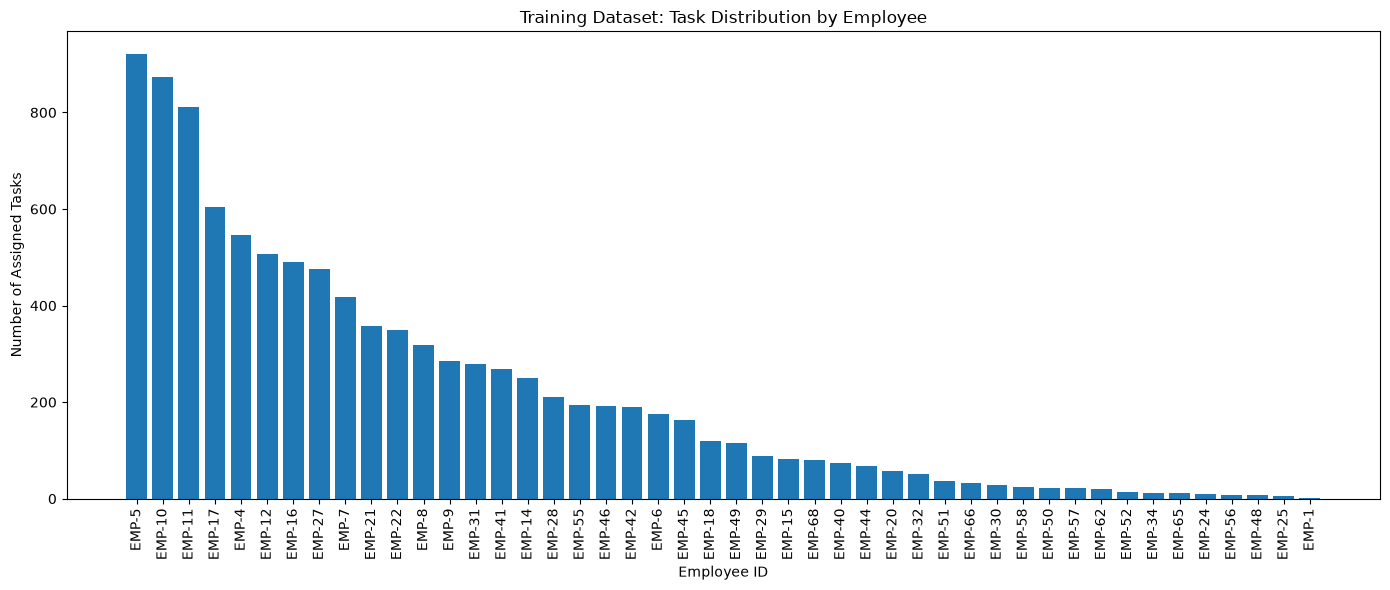

In [16]:
plt.figure(figsize=(14, 6))

plt.bar(
    imbalance_df["Employee_ID"],
    imbalance_df["Task_Count"]
)

plt.xlabel("Employee ID")
plt.ylabel("Number of Assigned Tasks")
plt.title("Training Dataset: Task Distribution by Employee")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [17]:
max_count = employee_counts.max()
min_count = employee_counts.min()

imbalance_ratio = max_count / min_count

print(f"Most frequent employee: {employee_counts.index[0]}")
print(f"Most frequent employee task count: {max_count}")

print(f"\nLeast frequent employee: {employee_counts.index[-1]}")
print(f"Least frequent employee task count: {min_count}")

print(f"\nMax/Min imbalance ratio: {imbalance_ratio:.2f}")

Most frequent employee: EMP-5
Most frequent employee task count: 922

Least frequent employee: EMP-1
Least frequent employee task count: 2

Max/Min imbalance ratio: 461.00


In [18]:
print("Employees with <= 5 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] <= 5])

print("\nEmployees with <= 10 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] <= 10])

print("\nEmployees with > 100 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] > 100])

Employees with <= 5 tasks:


,Employee_ID,Task_Count,Percentage
45,EMP-1,2,0.02



Employees with <= 10 tasks:


,Employee_ID,Task_Count,Percentage
41,EMP-24,9,0.09
42,EMP-56,8,0.08
43,EMP-48,8,0.08
44,EMP-25,6,0.06
45,EMP-1,2,0.02



Employees with > 100 tasks:


,Employee_ID,Task_Count,Percentage
0,EMP-5,922,9.33
1,EMP-10,874,8.85
2,EMP-11,812,8.22
3,EMP-17,604,6.11
4,EMP-4,547,5.54
5,EMP-12,506,5.12
6,EMP-16,490,4.96
7,EMP-27,476,4.82
8,EMP-7,417,4.22
9,EMP-21,358,3.62


In [19]:
print("Total rows:", len(final_train_df))
print("Unique tasks:", final_train_df["Task_ID"].nunique())
print("Duplicate Task_ID rows:", final_train_df["Task_ID"].duplicated().sum())


Total rows: 9879
Unique tasks: 1709
Duplicate Task_ID rows: 8170


In [20]:
task_employee_check = (
    final_train_df.groupby("Task_ID")["Employee_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print("Total unique tasks:", task_employee_check.shape[0])
print("Tasks with exactly 1 employee:", (task_employee_check == 1).sum())
print("Tasks with multiple employees:", (task_employee_check > 1).sum())
print("Maximum employees per task:", task_employee_check.max())

print("Tasks assigned to multiple employees:")
display(task_employee_check[task_employee_check > 1])


Total unique tasks: 1709
Tasks with exactly 1 employee: 1352
Tasks with multiple employees: 357
Maximum employees per task: 29
Tasks assigned to multiple employees:


Task_ID
TSK-183     29
TSK-3       24
TSK-435     24
TSK-1394    20
TSK-597     20
            ..
TSK-1598     2
TSK-1492     2
TSK-976      2
TSK-1011     2
TSK-992      2
Name: Employee_ID, Length: 357, dtype: int64

In [21]:
# ============================================================
# CHECK 1: TASK ID LEAKAGE BETWEEN TRAIN / VALIDATION / TEST
# ============================================================

train_tasks = set(final_train_df["Task_ID"].unique())
val_tasks = set(final_val_df["Task_ID"].unique())
test_tasks = set(final_test_df["Task_ID"].unique())

print("Train unique tasks:", len(train_tasks))
print("Validation unique tasks:", len(val_tasks))
print("Test unique tasks:", len(test_tasks))

print("\nTask overlap:")
print("Train ∩ Validation:", len(train_tasks & val_tasks))
print("Train ∩ Test:", len(train_tasks & test_tasks))
print("Validation ∩ Test:", len(val_tasks & test_tasks))




Train unique tasks: 1709
Validation unique tasks: 366
Test unique tasks: 367

Task overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [22]:
train_employees = set(final_train_df["Employee_ID"].unique())
val_employees = set(final_val_df["Employee_ID"].unique())
test_employees = set(final_test_df["Employee_ID"].unique())

print("Employee coverage:")
print("Train employees:", len(train_employees))
print("Validation employees:", len(val_employees))
print("Test employees:", len(test_employees))

print("Employees in Val not in Train:", sorted(val_employees - train_employees))
print("Employees in Test not in Train:", sorted(test_employees - train_employees))


Employee coverage:
Train employees: 46
Validation employees: 26
Test employees: 29
Employees in Val not in Train: ['EMP-59']
Employees in Test not in Train: ['EMP-59', 'EMP-63', 'EMP-67']


In [23]:
# ============================================================
# CHECK 3: TASK → EMPLOYEE DISTRIBUTION IN EACH SPLIT
# ============================================================

def task_employee_distribution(df, name):
    counts = df.groupby("Task_ID")["Employee_ID"].nunique()

    print(f"\n{name}")
    print("-" * 40)
    print("Unique tasks:", len(counts))
    print("1 employee:", (counts == 1).sum())
    print("Multiple employees:", (counts > 1).sum())
    print("Maximum employees/task:", counts.max())


task_employee_distribution(final_train_df, "TRAIN")
task_employee_distribution(final_val_df, "VALIDATION")
task_employee_distribution(final_test_df, "TEST")


TRAIN
----------------------------------------
Unique tasks: 1709
1 employee: 1352
Multiple employees: 357
Maximum employees/task: 29

VALIDATION
----------------------------------------
Unique tasks: 366
1 employee: 314
Multiple employees: 52
Maximum employees/task: 11

TEST
----------------------------------------
Unique tasks: 367
1 employee: 334
Multiple employees: 33
Maximum employees/task: 4
